In [1]:
import os
import glob 
import torch
import numpy as np
import pandas as pd
from torch import nn
from PIL import Image
from tqdm import tqdm 
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ignite.engine import Engine
from ignite.metrics import Accuracy
import torchvision.transforms as transforms
from torch.utils.data import Dataset , random_split , DataLoader

In [2]:
torch.cuda.manual_seed(1383)
torch.manual_seed(1382)
torch.backends.cudnn.deterministic = True

In [3]:
image_size = 128
device = torch.device("cuda")

# Agumention data 

In [ ]:
import os
import cv2
import albumentations as A
import pathlib 

def augment_ultrasound_dataset_inplace(input_dir, num_aug=5):

    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
            border_mode=cv2.BORDER_REFLECT_101, p=0.5
        ),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
        A.CLAHE(clip_limit=2.0, p=0.3),
        A.GaussNoise(var_limit=(5, 20), p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3) 
    ])

    for addres_mask in tqdm(glob.glob( input_dir + "/*_mask.png" ) , desc="Data Agumention :)"):

        addres_image = addres_mask.replace("_mask.png" , ".png")

        image = cv2.imread(addres_image, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(addres_mask, cv2.IMREAD_GRAYSCALE)

        for i in tqdm(range(num_aug)):
            augmented = transform(image=image, mask=mask)

            img_aug = augmented['image']
            mask_aug = augmented['mask']

            cv2.imwrite(input_dir + "/" + pathlib.Path(addres_image).stem + f"_aug{i}.png" , img_aug)
            cv2.imwrite(input_dir + "/" + pathlib.Path(addres_image).stem + f"_aug{i}_mask.png", mask_aug)


In [ ]:
augment_ultrasound_dataset_inplace("./dataset/Dataset_BUSI_with_GT/benign", num_aug=10)

f:\app_data\python_based\Lib\site-packages\albumentations\core\validation.py:111: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\abolfazl\AppData\Local\Temp\ipykernel_6284\1400640014.py:18: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),
Data Agumention :): 100%|██████████| 437/437 [00:34<00:00, 12.55it/s]

✅ افزایش داده‌ها انجام شد و در همان پوشه ذخیره شدند.


In [ ]:
augment_ultrasound_dataset_inplace("./dataset/Dataset_BUSI_with_GT/malignant", num_aug=10)

C:\Users\abolfazl\AppData\Local\Temp\ipykernel_6284\1400640014.py:18: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),
Data Agumention :): 100%|██████████| 210/210 [00:32<00:00,  6.43it/s]

✅ افزایش داده‌ها انجام شد و در همان پوشه ذخیره شدند.


In [ ]:
augment_ultrasound_dataset_inplace("./dataset/Dataset_BUSI_with_GT/normal", num_aug=10)

C:\Users\abolfazl\AppData\Local\Temp\ipykernel_6284\1400640014.py:18: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),
Data Agumention :): 100%|██████████| 133/133 [00:32<00:00,  4.12it/s]


✅ افزایش داده‌ها انجام شد و در همان پوشه ذخیره شدند.


## datasets 

In [4]:
class Datasets(Dataset):
    def __init__(self , addres_folder : str = "./dataset/Dataset_BUSI_with_GT" , image_transform : transforms = None ) -> None:
        super().__init__() 
        
        self._image_transform = image_transform 
        self._datasets = self.__processing__(addres_folder)
        
    def __processing__(self , addres ):
        masks = glob.glob(f"{addres}/*/*_mask.png")

        return pd.DataFrame(
            list(
                zip(
                    [mask_images.replace("_mask", "") for mask_images in masks] , 
                    masks
                )
            ) , 
            columns=[
                'image_path', 
                'mask_path'
            ]
        )
        
    def __len__(self):
        return len(self._datasets)

    def __getitem__(self, idx : int ):
        
        _data = self._datasets.iloc[idx]
        
        return ( 
            self._image_transform(
                Image.open(_data['image_path']).convert('L') # L 
            ) , 
            self._image_transform(
                Image.open(_data['mask_path']).convert('L') # L
            ) 
        )

datasets = Datasets(
    addres_folder = "./dataset/Dataset_BUSI_with_GT" , 
    
    image_transform= transforms.Compose([
        transforms.Resize([image_size , image_size ]),
        transforms.ToTensor() ,
        # transforms.Normalize(mean=0.3403 , std=0.1883)
    ])
)

train_data, valid_data , test_data = random_split(datasets, [0.8 , 0.1 , 0.1 ] , generator=torch.Generator().manual_seed(42))

train_dataloder =  DataLoader( train_data, batch_size= 10, shuffle= True ) # num_workers= os.cpu_count()
valid_dataloder =  DataLoader( valid_data, batch_size= 10, shuffle= False ) # num_workers= os.cpu_count()
test_dataloder =  DataLoader( test_data, batch_size= 10, shuffle= False ) # num_workers= os.cpu_count()


## model 

In [5]:
class ChannelAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channel // reduction, channel, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return x * self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.concat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return x * self.sigmoid(out) 
    
class CBAM(nn.Module):
    def __init__(self, channel, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channel, reduction)
        self.sa = SpatialAttention(kernel_size)
    
    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

class BlockEncoder(nn.Module):
    def __init__(self , in_channels : int , out_channels : int , kernel_size : int = 3 , stride : int = 1 , padding : int = 1 , dropout : float = 0.1 , maxpooling : bool = True , inedxing : int = 0) -> None:
        super().__init__()
        
        self._maxpooling = maxpooling 

        self._model = nn.Sequential(*self.__processing__(
            dim=inedxing , 
            in_channels=in_channels , 
            out_channels= out_channels , 
            kernel_size=kernel_size , stride=stride , 
            padding=padding , dropout=dropout
            )
        ) 
        
        self._maxpool = nn.Sequential(
            nn.MaxPool2d(kernel_size=2) , 
            nn.Dropout(dropout) 
        )
        
    def __processing__(self , dim : int , in_channels : int , out_channels : int , kernel_size : int , stride : int , padding : int , dropout : int ):
        data = [
            nn.Conv2d(in_channels = in_channels , out_channels = out_channels , kernel_size = kernel_size , stride = stride , padding = padding ) ,
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            
            nn.Dropout(dropout) ,
        ]
        
        for _ in range(dim):
            
            data += [
                nn.Conv2d(in_channels = out_channels , out_channels = out_channels , kernel_size = kernel_size , stride = stride , padding = padding ) ,
                CBAM(out_channels) , 
                nn.BatchNorm2d(out_channels),
                nn.ReLU() , 
                nn.Dropout(dropout) ,
            ]
        
        return data 

    def forward(self , input_ids : torch.Tensor ):
        
        _ = self._model(input_ids) 
        
        return _ , self._maxpool(_) if self._maxpooling else None 

class BlockDecoderAtnn(nn.Module):
    def __init__(self , in_channels : int , out_channels : int , kernel_size : int = 2 ,  stride : int = 2 , padding : int = 0 , dropout : float = 0.1 ) -> None:
        super().__init__()
        
        self._model = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels = in_channels , out_channels = out_channels , kernel_size=kernel_size , stride=stride , padding = padding 
            ) , 
            nn.Sigmoid() , 
            nn.Dropout(dropout) 
        )
        
    def forward(self , input_ids : torch.Tensor ):
        return self._model(input_ids)

class Model(nn.Module):
    def __init__(self ,  in_channels: int, out_channels: int , dim : int = 2) -> None:
        super().__init__()
        
        self._dim = dim
        self._controller = self.__processing_()
        
        self._model_0 = BlockEncoder(in_channels , 64 , 3 )
        
        self._model_1 = nn.ModuleList([
            BlockEncoder(64 , 128 , 3 , inedxing= self._controller[_] ) for _ in range( self._dim )
        ])
        
        self._model_2 = nn.ModuleList([
            BlockEncoder(128 , 256 , 3 , inedxing= self._controller[_] ) for _ in range( self._dim ** 2  )
        ])
        
        self._model_3 = nn.ModuleList([
            BlockEncoder(256 , 512 , 3 , inedxing= self._controller[_] ) for _ in range(self._dim ** 3 )
        ]) 
        
        self._model_4 = nn.ModuleList([
            BlockEncoder(512 , 1024 , 3 , maxpooling=False , inedxing= self._controller[_] ) for _ in range( self._dim ** 4 )
        ])
        
        self._model_4_decoder = nn.ModuleList([
            BlockDecoderAtnn(1024 * self._dim , 512 ) for _ in range(self._dim ** 3)
        ])
        
        self._model_4_decoder_up = nn.ModuleList([
            BlockEncoder(1024 , 512 , maxpooling=False ) for _ in range(self._dim ** 3 )
        ])
        
        self._model_5_decoder = nn.ModuleList([
            BlockDecoderAtnn(512 * self._dim , 256 ) for _ in range(self._dim ** 2)
        ])
        
        self._model_5_decoder_up = nn.ModuleList([
            BlockEncoder(512 , 256 , maxpooling=False ) for _ in range(self._dim ** 2)
        ])
        
        self._model_6_decoder = nn.ModuleList([
            BlockDecoderAtnn(256 * self._dim, 128 ) for _ in range(self._dim )
        ])
        
        self._model_6_decoder_up = nn.ModuleList([
            BlockEncoder(256 , 128 , maxpooling=False ) for _ in range(self._dim )
        ])
        
        self._conv_hidden_1 = nn.Sequential(
            nn.Conv3d(in_channels= self._dim , out_channels= self._dim , kernel_size=1 , stride= 1 , bias = False ) , 
            nn.BatchNorm3d(self._dim),
            nn.Dropout(0.1)
        )
        
        self._conv_hidden_2 = nn.Sequential(
            nn.Conv3d(in_channels= self._dim ** 2 , out_channels= self._dim ** 2 , kernel_size=1 , stride= 1 , bias = False ) , 
            nn.BatchNorm3d(self._dim ** 2) , 
            nn.Dropout()
        )
        
        self._conv_hidden_3 = nn.Sequential(
            nn.Conv3d(in_channels= self._dim ** 3 , out_channels= self._dim ** 3 , kernel_size=1 , stride= 1 , bias = False ) ,
            nn.BatchNorm3d(self._dim ** 3) ,
            nn.Dropout(0.1) 
        )
        
        self._conv_hidden_4 = nn.Sequential(
            nn.Conv3d(in_channels= self._dim ** 4 , out_channels= self._dim ** 4 , kernel_size=1 , stride= 1 , bias = False ) ,
            nn.BatchNorm3d(self._dim ** 4) ,
            nn.Dropout(0.1) 
        )

        self._model_7_decoder = BlockDecoderAtnn(128 * self._dim , 64 ) 
        
        self._model_7_decoder_up = BlockEncoder(128 , 64 , maxpooling=False )
        
        self._model_8_decoder = nn.Conv2d(64, out_channels , kernel_size=1)
        
        self._sigmoid = nn.Sigmoid()
        
    def __processing_(self):
        data = []
        
        for _ in range(self._dim ** 4):
            data += [ _ for _ in range(self._dim) ]
            
        return data 

    def forward(self , img : torch.Tensor ):
        
        hidden_0 , max_0 = self._model_0(img) 
        
        # Encoder hidden  
        _hidden_1 = torch.zeros( self._dim                                     , img.size(0) , 128  , int( image_size / 2             ) , int(image_size / 2             ) ).to(img.device)
        _hidden_2 = torch.zeros( self._dim * self._dim                         , img.size(0) , 256  , int( image_size / 2 / 2         ) , int(image_size / 2 / 2         ) ).to(img.device)
        _hidden_3 = torch.zeros( self._dim * self._dim * self._dim             , img.size(0) , 512  , int( image_size / 2 / 2 / 2     ) , int(image_size / 2 / 2 / 2     ) ).to(img.device)
        _hidden_4 = torch.zeros( self._dim * self._dim * self._dim * self._dim , img.size(0) , 1024 , int( image_size / 2 / 2 / 2 / 2 ) , int(image_size / 2 / 2 / 2 / 2 ) ).to(img.device)
        
        # Decoder hidden 
        _decoder   = torch.zeros( int( _hidden_4.size(0)  / self._dim ) , img.size(0) , 512 , int( image_size / 2 / 2 / 2 ) , int(image_size / 2 / 2 / 2 ) ).to(img.device)
        _decoder_1 = torch.zeros( int( _decoder.size(0)   / self._dim ) , img.size(0) , 256 , int( image_size / 2 / 2     ) , int(image_size / 2 / 2     ) ).to(img.device) 
        _decoder_2 = torch.zeros( int( _decoder_1.size(0) / self._dim ) , img.size(0) , 128 , int( image_size / 2         ) , int(image_size / 2         ) ).to(img.device) 
        
        for i , input1 in enumerate([max_0 , max_0 ]) : 
            
            out2 , max_2 = self._model_1[i](input1) 
            
            _hidden_1[i] = out2
            
            for j , input2 in enumerate([max_2 , max_2 ]) : 
                
                out3 , max_3 = self._model_2[j + i * self._dim](input2) 
                
                _hidden_2[j + i * self._dim] = out3
                
                for k , input3 in enumerate([max_3 , max_3 ]) : 
                    
                    out4 , max_4 = self._model_3[ ( j + i * self._dim ) * self._dim + k ](input3) 
                    
                    _hidden_3[ ( j + i * self._dim ) * self._dim + k ] = out4
                    
                    for f , input4 in enumerate([max_4 , max_4 ]) : 
                        
                        out5 , _ = self._model_4[ ( ( j + i * self._dim ) * self._dim + k ) * self._dim + f ](input4) 
                        
                        _hidden_4[ ( ( j + i * self._dim ) * self._dim + k ) * self._dim + f ] = out5

        _hidden_1 = self._conv_hidden_1(_hidden_1.permute( 1 , 0 , 2 , 3 , 4 )).permute( 1 , 0 , 2 , 3 , 4 )
        _hidden_2 = self._conv_hidden_2(_hidden_2.permute( 1 , 0 , 2 , 3 , 4 )).permute( 1 , 0 , 2 , 3 , 4 )
        _hidden_3 = self._conv_hidden_3(_hidden_3.permute( 1 , 0 , 2 , 3 , 4 )).permute( 1 , 0 , 2 , 3 , 4 )
        _hidden_4 = self._conv_hidden_4(_hidden_4.permute( 1 , 0 , 2 , 3 , 4 )).permute( 1 , 0 , 2 , 3 , 4 )

        for i , _ in enumerate(range( int( _hidden_4.size(0) / self._dim ) )):

            _decoder[i] = self._model_4_decoder_up[i](
                    torch.cat([ 
                        self._model_4_decoder[i](_hidden_4[ _ * self._dim  :  _ * self._dim + self._dim , : , : , :].permute( 1 , 0 , 2 , 3 , 4).flatten(start_dim = 1, end_dim=2)) , 
                        _hidden_3[i] 
                    ] , dim=1) 
                )[0]

        for i , _ in enumerate(range( int( _decoder.size(0) / self._dim ) )):

            _decoder_1[i] = self._model_5_decoder_up[i](
                torch.cat([ 
                        self._model_5_decoder[i](_decoder[ _ * self._dim  :  _ * self._dim + self._dim , : , : , :].permute( 1 , 0 , 2 , 3 , 4).flatten(start_dim = 1, end_dim=2)) , 
                        _hidden_2[i] 
                    ] , dim=1
                ) 
            )[0]

        for i , _ in enumerate(range( int( _decoder_1.size(0) / self._dim ) )):

            _decoder_2[i] = self._model_6_decoder_up[i](
                    torch.cat([ 
                        self._model_6_decoder[i](_decoder_1[ _ * self._dim  :  _ * self._dim + self._dim , : , : , :].permute( 1 , 0 , 2 , 3 , 4).flatten(start_dim = 1, end_dim=2)) , 
                        _hidden_1[i] 
                    ] , 
                    dim=1
                ) 
            )[0]

        return self._sigmoid(
            self._model_8_decoder(
                self._model_7_decoder_up(
                    torch.cat([ self._model_7_decoder(_decoder_2.permute( 1 , 0 , 2 , 3 , 4).flatten(start_dim = 1, end_dim=2)) , hidden_0 ] , dim=1) 
                )[0]
            )
        )

## running model 

In [6]:
unet = Model( in_channels=1 , out_channels=1 ).to(device)

## load wight model 

In [15]:
unet.load_state_dict(torch.load("./best_model_epoch<  _epoch_ >_dice< _iou_ >.pt"))

## train 

In [7]:
class Trainer:
    def __init__(self, model, num_epochs, optimizer, criterion, device):
        self.num_epochs = num_epochs
        self.optimizer = optimizer
        self.criterion = criterion
        self.model = model
        self.device = device
        self.log_interval = 15

        # Lists to store training and validation metrics
        self.train_losses = []
        self.val_losses = []
        self.train_dices = []
        self.val_dices = []

        # Best model and its metrics
        self.best_model = None
        self.best_dice = 0.0
        self.best_epoch = 0

    def dice_coeff(self, predicted, target, smooth=1e-5):

        predicted = (predicted >= 0.5).float()

        intersection = torch.sum(predicted * target)
        union = torch.sum(predicted) + torch.sum(target)
        dice = (2. * intersection + smooth) / (union + smooth)
        return dice
    
    def iou(self, pred_mask, true_mask):
        intersection = torch.logical_and(pred_mask, true_mask).sum().item()
        union = torch.logical_or(pred_mask, true_mask).sum().item()
        iou_score = intersection / union if union != 0 else 0.0
        return iou_score

    def save_best_model(self, epoch, dice):
        if dice > self.best_dice:
            
            if self.best_epoch :
                os.remove(f'best_model_epoch{self.best_epoch}_dice{self.best_dice:.4f}.pt')
            
            
            self.best_dice = dice
            self.best_epoch = epoch
            self.best_model = self.model.state_dict()

            filename = f'best_model_epoch{epoch}_dice{dice:.4f}.pt'
            torch.save(self.best_model, filename)

    def train(self, train_loader, val_loader):
        for epoch in range(self.num_epochs):
            train_loss = 0.0
            val_loss = 0.0
            train_dice = 0.0
            val_dice = 0.0

            # Training loop
            for i, (images, masks) in enumerate(train_loader):
                images, masks = images.to(self.device), masks.to(self.device)

                self.model.train()
                self.optimizer.zero_grad()

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                dice = self.dice_coeff(outputs, masks)

                loss.backward()
                self.optimizer.step()

                train_loss += loss.item()
                train_dice += dice

                if (i + 1) % self.log_interval == 0:
                    print(f'Epoch [{epoch + 1}/{self.num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {loss.item():.4f}, Dice Coef: {dice:.4f}')

            # Validation loop
            self.model.eval()
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(self.device), masks.to(self.device)
                    outputs = self.model(images)
                    val_loss += self.criterion(outputs, masks).item()
                    val_dice += self.dice_coeff(outputs, masks)

            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)
            avg_train_dice = train_dice / len(train_loader)
            avg_val_dice = val_dice / len(val_loader)

            print(f'Epoch [{epoch + 1}/{self.num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
            print(f'Epoch [{epoch + 1}/{self.num_epochs}], Train Dice: {avg_train_dice:.4f}, Val Dice: {avg_val_dice:.4f}')

            # Save metrics
            self.train_losses.append(avg_train_loss)
            self.val_losses.append(avg_val_loss)
            self.train_dices.append(avg_train_dice)
            self.val_dices.append(avg_val_dice)

            # Save best model
            self.save_best_model(epoch + 1, avg_val_dice)
            
    def get_metrics(self):
        return {
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_dices': self.train_dices,
            'val_dices': self.val_dices,
            'best_model': self.best_model,
            'best_dice': self.best_dice,
            'best_epoch': self.best_epoch
        }

In [8]:
def dice_coef_loss(inputs, target):
    smooth = 1e-6
    intersection = 2.0 * (target*inputs).sum() + smooth
    union = target.sum() + inputs.sum() + smooth
    return 1 - (intersection/union)

def bce_dice_loss(inputs, target):
    dice_score = dice_coef_loss(inputs, target)
    
    bce_loss = F.binary_cross_entropy( inputs , target )

    return bce_loss + dice_score

In [9]:
optimizer = optim.AdamW(unet.parameters(), lr=0.0001, weight_decay=1e-6 )

# optimizer_lr = optim.lr_scheduler.StepLR(optimizer , step_size=50 , gamma=0.1)

trainer = Trainer(model=unet , num_epochs=10 , optimizer=optimizer , criterion=bce_dice_loss , device=device )

In [10]:
trainer.train(train_dataloder, valid_dataloder)
metrics = trainer.get_metrics()

Epoch [1/10], Step [15/687], Loss: 1.3787, Dice Coef: 0.1001
Epoch [1/10], Step [30/687], Loss: 1.3497, Dice Coef: 0.2425
Epoch [1/10], Step [45/687], Loss: 1.2838, Dice Coef: 0.3410
Epoch [1/10], Step [60/687], Loss: 1.1547, Dice Coef: 0.5152
Epoch [1/10], Step [75/687], Loss: 1.1297, Dice Coef: 0.5263
Epoch [1/10], Step [90/687], Loss: 0.9323, Dice Coef: 0.7131
Epoch [1/10], Step [105/687], Loss: 1.0873, Dice Coef: 0.5103
Epoch [1/10], Step [120/687], Loss: 1.1754, Dice Coef: 0.3742
Epoch [1/10], Step [135/687], Loss: 1.0692, Dice Coef: 0.5857
Epoch [1/10], Step [150/687], Loss: 1.0608, Dice Coef: 0.5093
Epoch [1/10], Step [165/687], Loss: 0.8920, Dice Coef: 0.6135
Epoch [1/10], Step [180/687], Loss: 1.1187, Dice Coef: 0.4044
Epoch [1/10], Step [195/687], Loss: 0.8459, Dice Coef: 0.6772
Epoch [1/10], Step [210/687], Loss: 1.3169, Dice Coef: 0.0749
Epoch [1/10], Step [225/687], Loss: 0.8514, Dice Coef: 0.6855
Epoch [1/10], Step [240/687], Loss: 1.1047, Dice Coef: 0.4034
Epoch [1/10], 

## create testing matrix 

In [11]:
metrics = trainer.get_metrics()

## Saved metric

In [12]:
torch.save( metrics , "./history.pt")

## show

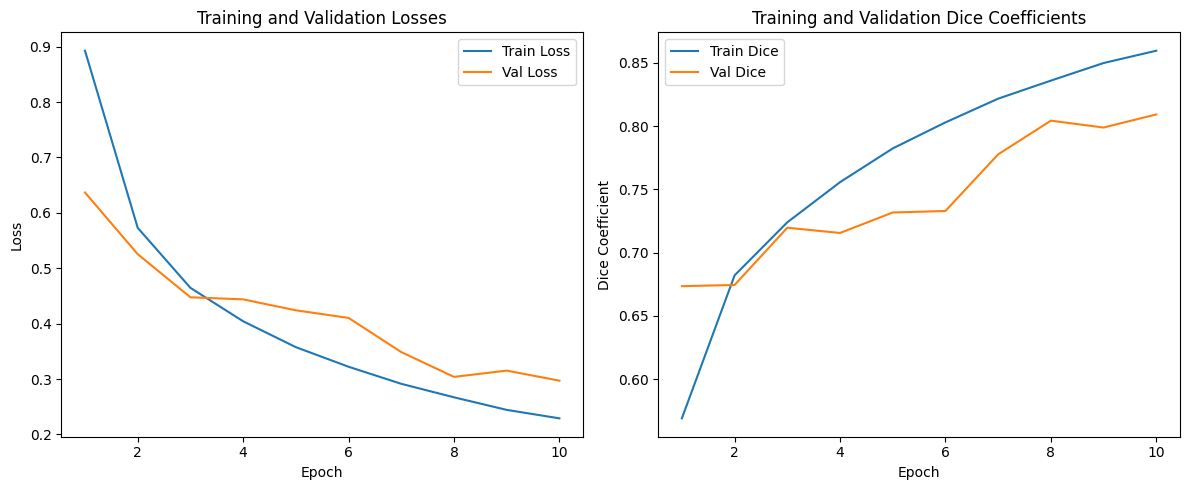

In [13]:
def to_numpy(tensor):
    # Move tensor to CPU and convert to NumPy array
    return tensor.cpu().detach().item()

def plot_metrics(metrics):
    num_epochs = len(metrics['train_losses'])
    epochs = np.arange(1, num_epochs + 1)

    # Convert tensors to NumPy arrays
    train_losses_np = metrics['train_losses']
    val_losses_np = metrics['val_losses']
    train_dices_np = [to_numpy(dice) for dice in metrics['train_dices']]
    val_dices_np = [to_numpy(dice) for dice in metrics['val_dices']]

    # Plot Losses
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses_np, label='Train Loss')
    plt.plot(epochs, val_losses_np, label='Val Loss')
    plt.title('Training and Validation Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Dice Coefficients
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_dices_np, label='Train Dice')
    plt.plot(epochs, val_dices_np, label='Val Dice')
    plt.title('Training and Validation Dice Coefficients')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_metrics(metrics)

## validate the validation 

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def to_numpy(tensor):
    # Move tensor to CPU and convert to NumPy array
    return tensor.cpu().detach().numpy()

def threshold_prediction(predicted, threshold=0.5):
    # Threshold predicted values
    predicted[predicted < threshold] = 0
    predicted[predicted >= threshold] = 1
    return predicted

def plot_subplots(image, mask, predicted, threshold=0.5):
    # Convert tensors to NumPy arrays
    image_np, mask_np, predicted_np = map(to_numpy, (image, mask, predicted))

    # Threshold the predicted values
    predicted_np_thresholded = threshold_prediction(predicted_np, threshold)

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))  # Adjust figsize as needed

    # Plot Image, Mask, Predicted, and Thresholded Predicted
    titles = ['Image', 'Mask', 'Predicted']
    for ax, data, title in zip(axes, [image_np, mask_np, predicted_np, predicted_np_thresholded], titles):
        ax.imshow(data.squeeze(), cmap='gray' if 'Mask' in title else 'gray')
        ax.set_title(title)
        ax.axis('off')

    plt.show()

## show predictions

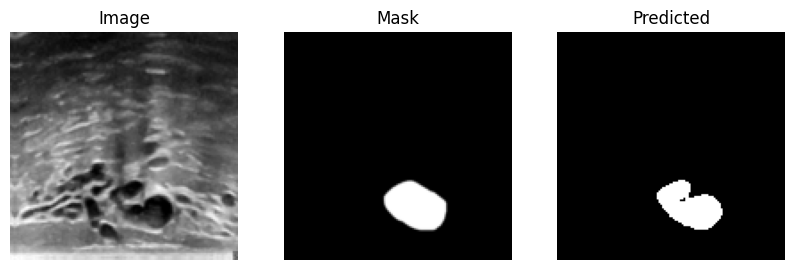

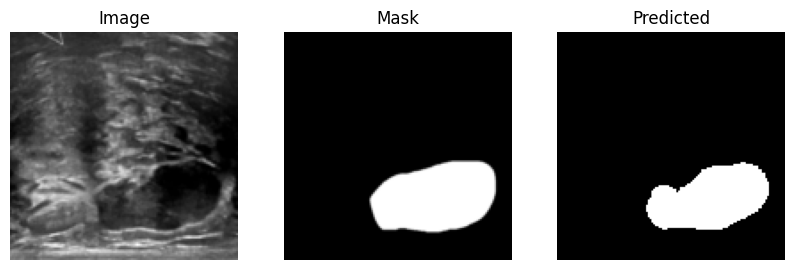

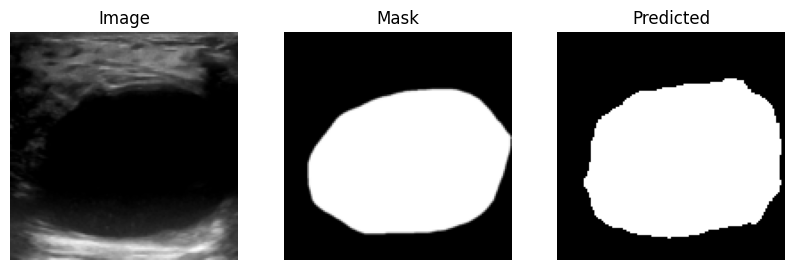

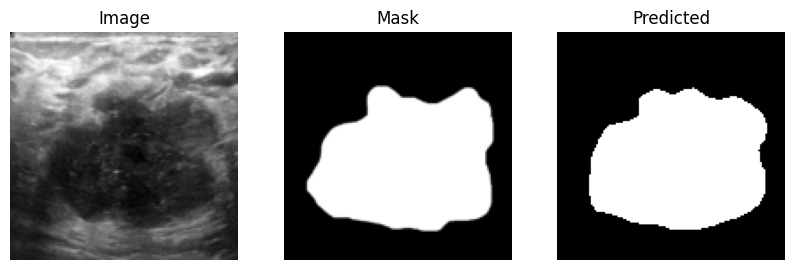

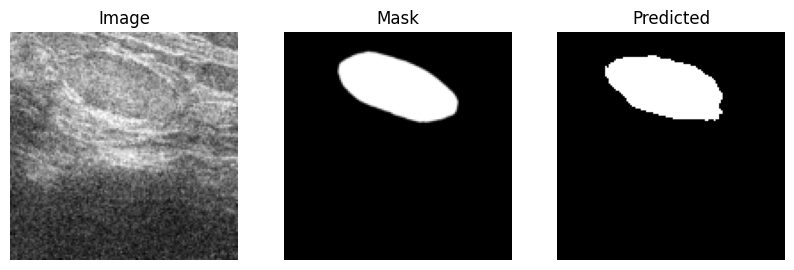

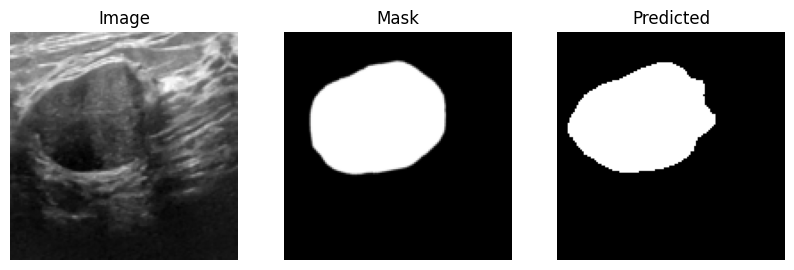

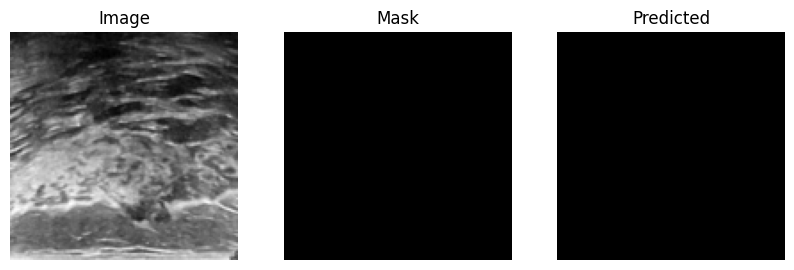

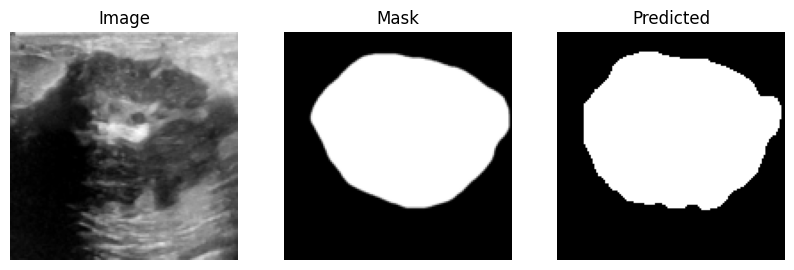

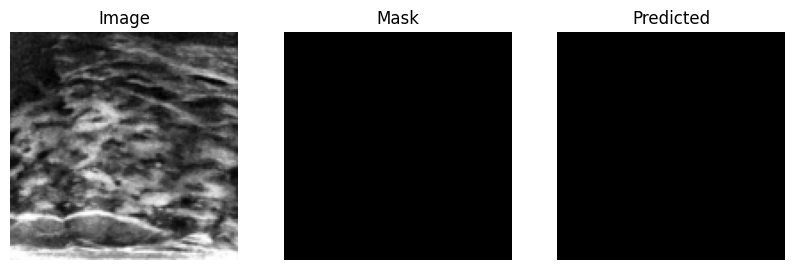

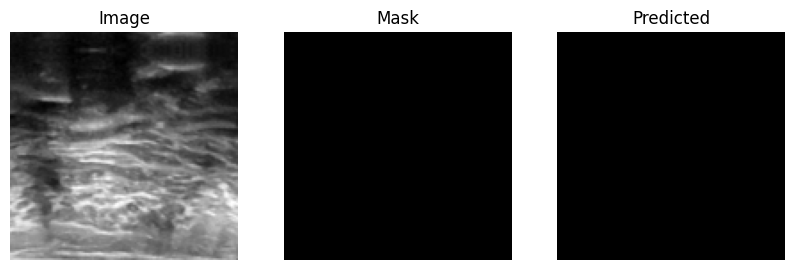

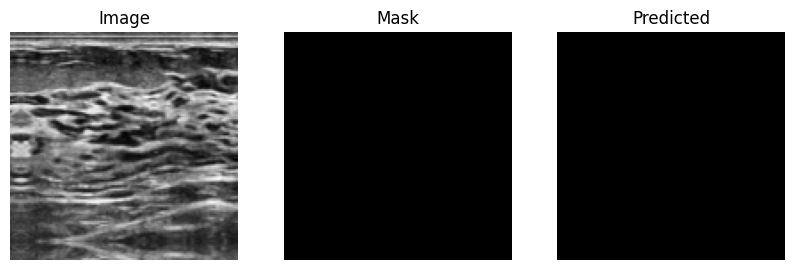

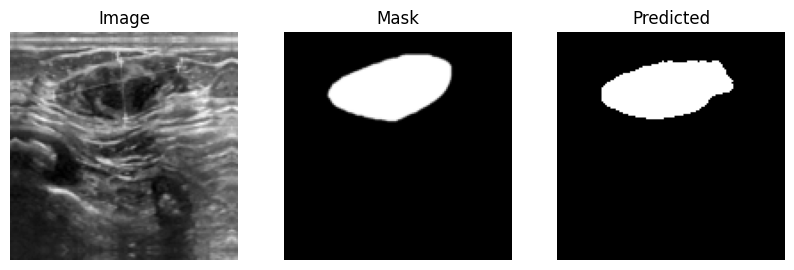

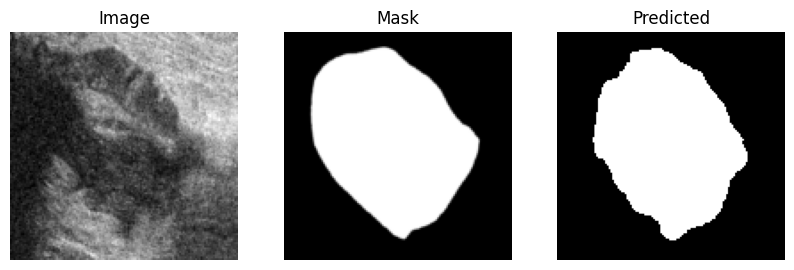

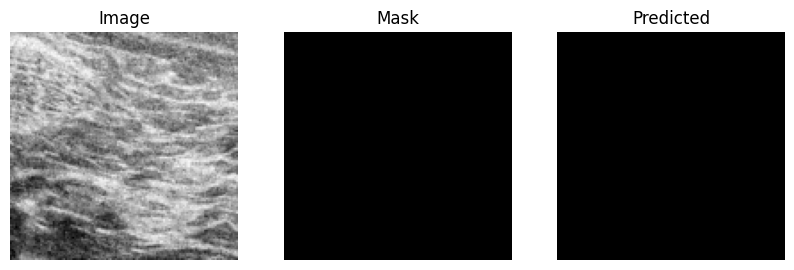

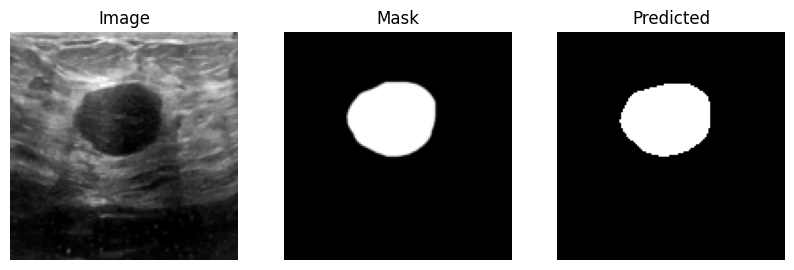

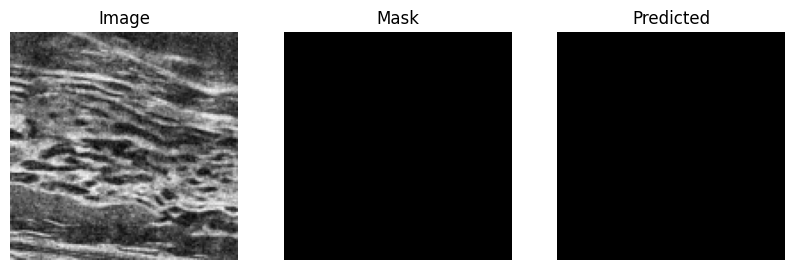

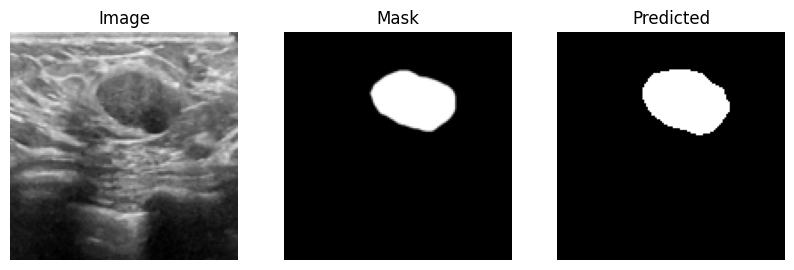

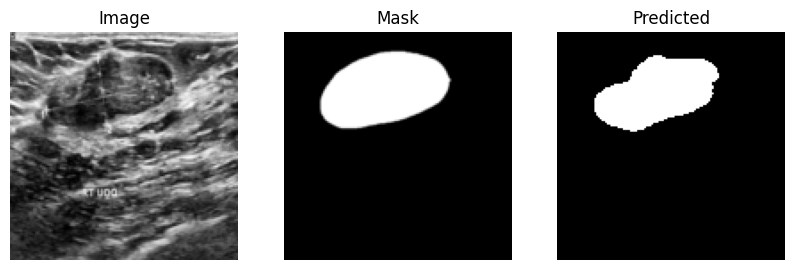

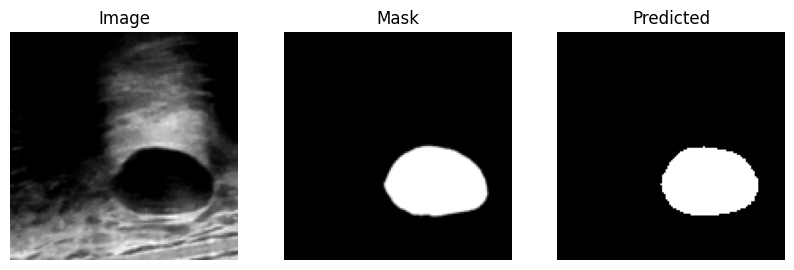

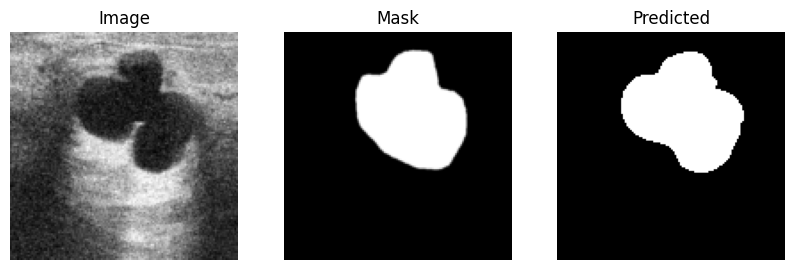

In [15]:
i = 0 
threshold = 0.9
batch = 20 

def dice_coeff(predicted, target, smooth=1e-5):
    predicted = (predicted >= 0.5).float()
    intersection = torch.sum(predicted * target)
    union = torch.sum(predicted) + torch.sum(target)
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

unet.eval()
with torch.no_grad():
    for image , mask  in test_data:
        pred = unet(image.to(device).unsqueeze(0)).squeeze()

        if dice_coeff(pred.cpu() , mask) > threshold : 
            plot_subplots(image, mask, pred)
            i+=1

        if i == batch : 
            break 


## accuracy Model

In [16]:
accurecy = []

def threshold_prediction(predicted, threshold=0.5):
    predicted[predicted < threshold] = 0
    predicted[predicted >= threshold] = 1
    return predicted

def eval_step(engine, batch):
    return batch

metric = Accuracy()
metric.attach(( default_evaluator := Engine(eval_step) ), "accuracy")

for image , mask  in valid_data:

    pred = unet(image.to(device).unsqueeze(0))

    accurecy.append(
        default_evaluator.run([[threshold_prediction(pred).int(), mask.int()]]).metrics["accuracy"]
    )


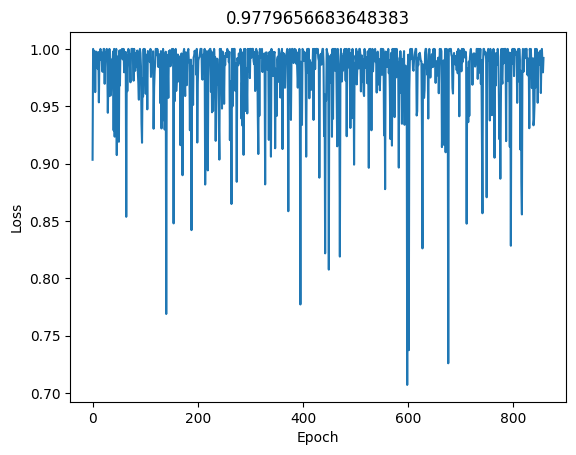

In [17]:
plt.plot(accurecy, label='Test acc')
plt.title(f'{sum(accurecy) / len(accurecy)}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()